In [3]:

import sys
import os
# Add parent directory ('notebooks') to the search path
sys.path.append(os.path.abspath(os.path.join('..')))



from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, format_ai_message


## Single Node Graph

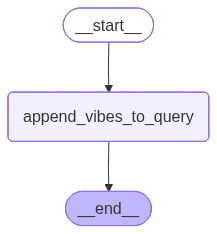

In [ ]:
# --- State Definition ---
class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str




# --- Node Function ---
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": f"{state.message} {state.vibe}"
    }



# --- Graph Construction ---
workflow = StateGraph(State)
workflow.add_node("append_vibes_to_query", append_vibes_to_query)

workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibes_to_query", END)


graph = workflow.compile()



# --- Display Graph ---
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# Test 1
initial_state = {
    "message": "Give me some vibes!",
    "vibe": "I'm feeling like a badass today!"
}

result = graph.invoke(initial_state)
print(result)
# Output:
# {'message': 'Give me some vibes!', 'answer': "Give me some vibes! I'm feeling like a badass today!", 'vibe': "I'm feeling like a badass today!"}




{'message': 'Give me some vibes!', 'answer': "Give me some vibes! I'm feeling like a badass today!", 'vibe': "I'm feeling like a badass today!"}


In [6]:
# Test 2 (Demonstrating answer state overwriting)
initial_state = {
    "message": "Give me some vibes!",
    "answer": "abc",
    "vibe": "I'm feeling like a badass today!"
}

result = graph.invoke(initial_state)
print(result)
# Output:
# {'message': 'Give me some vibes!', 'answer': "Give me some vibes! I'm feeling like a badass today!", 'vibe': "I'm feeling like a badass today!"}

{'message': 'Give me some vibes!', 'answer': "Give me some vibes! I'm feeling like a badass today!", 'vibe': "I'm feeling like a badass today!"}


## Conditional Graph

In [11]:
# --- State Definition ---
class State(BaseModel):
    message: str
    answer: str = ""


# --- Node Functions ---
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": "I am here to add some vibes:"
    }


# --- Router ---
def router(state: State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:
    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]
    vibe_path = random.choice(vibes)
    return vibe_path


# --- Conditional Node Functions ---
def append_vibe_1(state: State) -> dict:
    vibe = "I'm feeling like a badass today!"
    return {
        "answer": f"{state.answer} {vibe}"
    }

def append_vibe_2(state: State) -> dict:
    vibe = "I'm feeling like a boss today!"
    return {
        "answer": f"{state.answer} {vibe}"
    }

def append_vibe_3(state: State) -> dict:
    vibe = "I'm feeling like a legend today!"
    return {
        "answer": f"{state.answer} {vibe}"
    }


# --- Graph Construction ---
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

# Add routing decision based on router function output
workflow.add_conditional_edges(
    "append_vibes_to_query",
    router,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3"
    }
)

workflow.add_edge(START, "append_vibes_to_query")

workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()


In [29]:
initial_state = {
    "message": "I am here to add some vibes:",
}

# Run invocation (routes to a random vibe)
result = graph.invoke(initial_state)
print(result)


{'message': 'I am here to add some vibes:', 'answer': "I am here to add some vibes: I'm feeling like a legend today!"}
